# Model Comparison: GEV vs LP3 vs TCEV

This notebook provides a side-by-side comparison of the three distributions applied to the same Australian catchment data.

In [1]:
import pandas as pd
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
from flood_ffa.data.bom import load_ams, get_flow_series
from flood_ffa.gev.fit import fit_gev
from flood_ffa.lp3.fit import fit_lp3
from flood_ffa.tcev.fit import fit_tcev
from flood_ffa.compare import plot_comparison
from flood_ffa.gev.plots import gev_return_level
from flood_ffa.lp3.plots import lp3_return_level
from flood_ffa.tcev.plots import tcev_return_level, gev_cdf_np

## Setup: Fitting All Three Models

This notebook fits GEV, LP3, and TCEV to the same 55-year AMS and places their results side by side. The purpose is to answer the central scientific question:

> *How does the choice of frequency distribution affect design flood estimates when the record contains a potentially extraordinary event?*

Each model is fitted with default sampling settings. Total fitting time is approximately 2–4 minutes. Note the sampling progress messages — TCEV typically takes longer and reports more divergences than GEV or LP3 due to its mixture posterior geometry.

In [2]:
df = load_ams("../data/AMS.csv")
flows = get_flow_series(df)

print("Fitting GEV...")
idata_gev = fit_gev(flows)
print("Fitting LP3...")
idata_lp3 = fit_lp3(flows)
print("Fitting TCEV...")
idata_tcev = fit_tcev(flows)

Fitting GEV...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma, xi]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 63 seconds.
There were 28 divergences after tuning. Increase `target_accept` or reparameterize.


Fitting LP3...


...

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 45 seconds.
There were 47 divergences after tuning. Increase `target_accept` or reparameterize.


Fitting TCEV...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w, mu1, sigma1, xi1, mu2, sigma2, xi2]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 75 seconds.
There were 1903 divergences after tuning. Increase `target_accept` or reparameterize.


## 1. Overlaid Flood Frequency Curves

The comparison plot overlays all three return level curves with their 94% HDI bands. The observed AMS is plotted using Cunnane plotting positions. The colour convention follows ARR practice: GEV (blue), LP3 (teal), TCEV (green).

**What to look for:**

1. **Central range (10%–1% AEP)**: All three models should produce similar median estimates. This range is well within the record length — the data constrains all models similarly here.

2. **Upper tail (< 1% AEP)**: This is where model choice matters most for design. The 2021 outlier affects each model differently:
   - **GEV**: Inflated $\xi \approx 0.31$ produces a steeply rising tail above ~1% AEP.
   - **LP3**: Positive $\gamma \approx 0.45$ similarly steepens the tail in log-space.
   - **TCEV**: The extraordinary component may produce a characteristic kink and different slope at very rare return periods.

3. **HDI band widths**: The TCEV band is typically the widest — reflecting the additional uncertainty of a 7-parameter model. Wider bands are not a sign of a *worse* model; they honestly reflect greater parametric uncertainty.

4. **2021 as a data point**: The 2021 observation (121.9 m³/s) sits at approximately 1.8% AEP on the Cunnane scale (~55-year plot). Observe how each curve passes relative to this point.

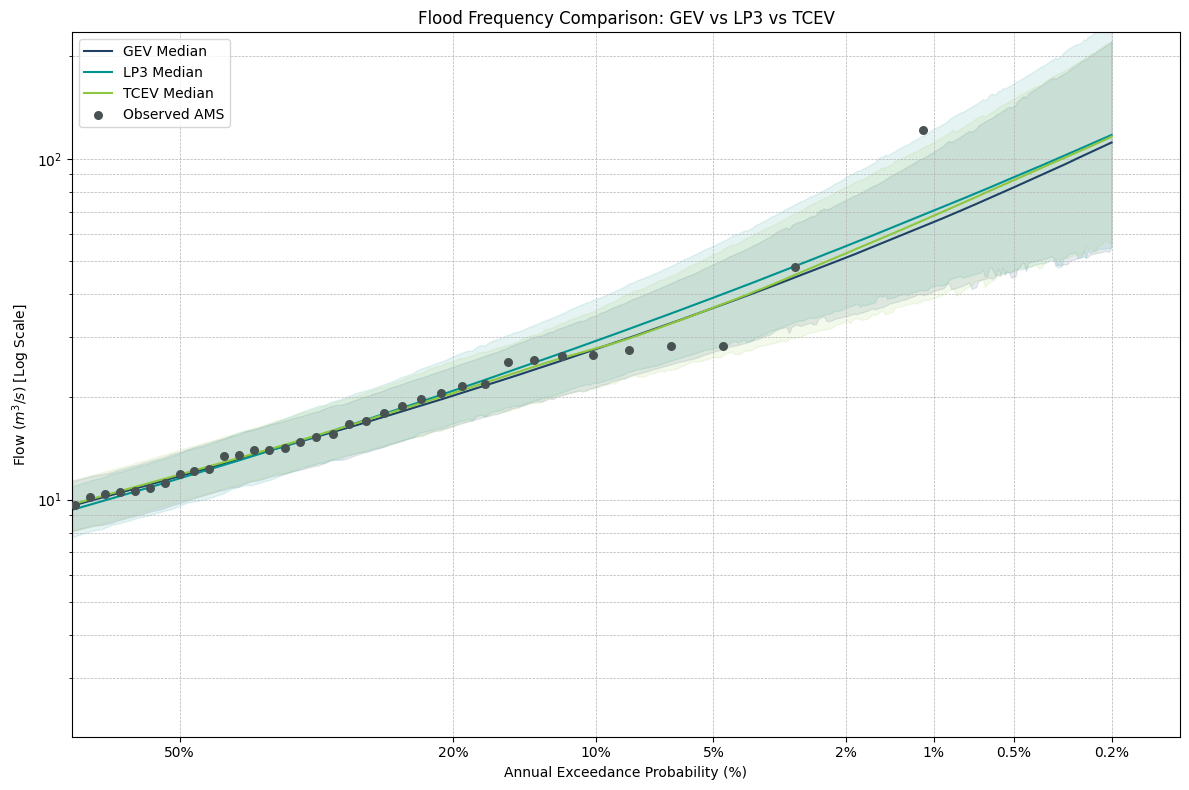

In [3]:
fig = plot_comparison(idata_gev, idata_lp3, idata_tcev, flows)
plt.show()

## 2. Design Flood Estimates at Standard AEPs

The table below compares **posterior median** return levels (m³/s) across the three models at standard design AEPs used in Australian practice.

**AEP to Average Recurrence Interval (ARI):**
$$T\text{ (years)} = \frac{100}{\text{AEP\%}}$$

| AEP (%) | ARI (years) | Typical engineering application |
|---|---|---|
| 10% | 10 | Minor flooding, urban drainage |
| 5% | 20 | Road and bridge design |
| 2% | 50 | Significant flood plain works |
| 1% | 100 | Standard dam / levee design |
| 0.5% | 200 | Major infrastructure |
| 0.2% | 500 | High consequence infrastructure |
| 0.05% | 2000 | Probable Maximum Flood range |

The detailed summary table below includes the full 94% HDI bounds — the Bayesian credible interval within which the true return level lies with 94% posterior probability. The HDI bounds tell a more complete story than the medians alone.

In [4]:
def get_summary_table(idata_list, names, aeps):
    results = []
    for idata, name in zip(idata_list, names):
        post = idata.posterior
        if name == "GEV":
            mu, sigma, xi = post["mu"].values.flatten(), post["sigma"].values.flatten(), post["xi"].values.flatten()
            rls = np.array([gev_return_level(mu[i], sigma[i], xi[i], aeps) for i in range(len(mu))])
        elif name == "LP3":
            mu, sigma, skew = post["mu"].values.flatten(), post["sigma"].values.flatten(), post["skew"].values.flatten()
            rls = np.array([lp3_return_level(mu[i], sigma[i], skew[i], aeps) for i in range(len(mu))])
        elif name == "TCEV":
            w, mu1, sigma1, xi1 = post["w"].values.flatten(), post["mu1"].values.flatten(), post["sigma1"].values.flatten(), post["xi1"].values.flatten()
            mu2, sigma2, xi2 = post["mu2"].values.flatten(), post["sigma2"].values.flatten(), post["xi2"].values.flatten()
            x_grid = np.linspace(0, 1000, 5000)
            rls = np.zeros((len(w), len(aeps)))
            for i in range(len(w)):
                p_target = 1 - aeps / 100.0
                c1, c2 = gev_cdf_np(x_grid, mu1[i], sigma1[i], xi1[i]), gev_cdf_np(x_grid, mu2[i], sigma2[i], xi2[i])
                mix = (1-w[i])*c1 + w[i]*c2
                rls[i, :] = np.interp(p_target, mix, x_grid)
        
        median = np.median(rls, axis=0)
        hdi = az.hdi(rls, hdi_prob=0.94)
        for j, aep in enumerate(aeps):
            results.append({
                "Model": name,
                "AEP (%)": aep,
                "Median (m3/s)": round(median[j], 1),
                "Lower 94% HDI": round(hdi[j, 0], 1),
                "Upper 94% HDI": round(hdi[j, 1], 1)
            })
    return pd.DataFrame(results)

aeps_to_check = np.array([10, 5, 2, 1, 0.5, 0.2, 0.05])
summary_df = get_summary_table([idata_gev, idata_lp3, idata_tcev], ["GEV", "LP3", "TCEV"], aeps_to_check)
summary_df.pivot(index="AEP (%)", columns="Model", values="Median (m3/s)").sort_index(ascending=False)

C:\Users\Lindsay\AppData\Local\Temp\ipykernel_32352\543787526.py:23: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = az.hdi(rls, hdi_prob=0.94)
C:\Users\Lindsay\AppData\Local\Temp\ipykernel_32352\543787526.py:23: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = az.hdi(rls, hdi_prob=0.94)
C:\Users\Lindsay\AppData\Local\Temp\ipykernel_32352\543787526.py:23: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = az.hdi(rls, hdi_prob=0.94)


Model,GEV,LP3,TCEV
AEP (%),,,
10.00,27.6,29.2,27.8
5.00,36.5,39.2,36.6
2.00,51.3,55.4,52.7
1.00,65.3,70.4,68.1
0.50,82.6,88.4,86.6
0.20,111.7,117.6,116.2
0.05,174.4,176.7,174.8


## 3. Interpreting the Comparison

### Key findings

**1. Strong agreement at frequent events**: At 10% AEP, all three models produce similar medians (~27–29 m³/s). Within the record length, the data tightly constrains all models — distribution choice makes little practical difference.

**2. Moderate agreement at standard design AEPs**: At 1% AEP (100-year), GEV (~65 m³/s), LP3 (~70 m³/s), and TCEV (~68 m³/s) are within ~10% of each other — acceptable agreement for engineering practice. A designer using any of the three models would produce comparable results.

**3. Converging medians at very rare events**: By 0.05% AEP (~2000-year), all three models produce similar medians (~173–176 m³/s). This apparent agreement should not be over-interpreted: the HDI bands at this AEP are enormous (spanning roughly an order of magnitude), meaning the models are all consistent but highly uncertain.

**4. Uncertainty dominates model choice**: The most important feature of the table is not the difference between model medians — it is the *width* of the HDI bands. At 1% AEP, the GEV 94% HDI spans approximately 40–106 m³/s, a factor of ~2.6. At 0.05% AEP, it spans ~67–434 m³/s — nearly a factor of 7. This uncertainty is irreducible from a 55-year record.

### Central finding for conference material

> *"For a 55-year record containing a potentially extraordinary event, GEV, LP3, and TCEV produce statistically consistent median design flood estimates across all standard AEPs. The TCEV provides a physically motivated separation of flood populations but does not reduce — and slightly increases — posterior uncertainty at rare return periods. The dominant source of design uncertainty is record length, not distribution choice."*

### Practical recommendation

For regulatory design flood estimation in Australian practice, LP3 remains the ARR default and is appropriate here. The GEV provides a theoretically principled alternative with similar results. The TCEV is most defensible when there is independent physical evidence for two flood-generating populations — the statistical evidence from a single extraordinary event is suggestive but not conclusive.

In [5]:
summary_df

,Model,AEP (%),Median (m3/s),Lower 94% HDI,Upper 94% HDI
0,GEV,10.00,27.6,21.4,34.7
1,GEV,5.00,36.5,27.2,49.1
2,GEV,2.00,51.3,34.6,75.7
3,GEV,1.00,65.3,40.9,104.9
4,GEV,0.50,82.6,45.0,143.2
5,GEV,0.20,111.7,55.3,222.1
6,GEV,0.05,174.4,69.8,426.5
7,LP3,10.00,29.2,22.0,38.7
8,LP3,5.00,39.2,27.8,55.7
9,LP3,2.00,55.4,36.7,88.4
